In [1]:
'''
SALGININ ŞİDDETİ (REPRODUCTİON & HASTANE)
reproduction_rate	R değeri — bir hastanın ortalama kaç kişiyi enfekte ettiği
(1'in üstü = yayılıyor, altı = yavaşlıyor)
icu_patients / icu_patients_per_million	
hosp_patients / hosp_patients_per_million	Hastanede yatan hasta sayısı
weekly_icu_admissions / weekly_hosp_admissions	Haftalık yeni yoğun bakım/hastane girişleri
(çok az ülke bu veriyi paylaşmış — dolu satır sayısı çok düşük: ~11.000-24.000)
'''

"\nSALGININ ŞİDDETİ (REPRODUCTİON & HASTANE)\nreproduction_rate\tR değeri — bir hastanın ortalama kaç kişiyi enfekte ettiği\n(1'in üstü = yayılıyor, altı = yavaşlıyor)\nicu_patients / icu_patients_per_million\t\nhosp_patients / hosp_patients_per_million\tHastanede yatan hasta sayısı\nweekly_icu_admissions / weekly_hosp_admissions\tHaftalık yeni yoğun bakım/hastane girişleri\n(çok az ülke bu veriyi paylaşmış — dolu satır sayısı çok düşük: ~11.000-24.000)\n"

In [ ]:
'''
stringency_index	Hükümetin kısıtlama sertliği endeksi (0-100, kapanma/maske zorunluluğu vb.)
hospital_beds_per_thousand	Bin kişiye düşen hastane yatağı
population	Toplam nüfus
'''

'\nstringency_index\tHükümetin kısıtlama sertliği endeksi (0-100, kapanma/maske zorunluluğu vb.)\npopulation_density\tNüfus yoğunluğu (km² başına kişi)\nmedian_age\tMedyan yaş\naged_65_older / aged_70_older\tNüfusun 65/70 yaş üstü yüzdesi\ngdp_per_capita\tKişi başı GSYH\nextreme_poverty\tAşırı yoksulluk oranı\ncardiovasc_death_rate\tKardiyovasküler hastalık ölüm oranı\ndiabetes_prevalence\tDiyabet yaygınlığı\nfemale_smokers / male_smokers\tSigara içme oranları (cinsiyete göre)\nhandwashing_facilities\tEl yıkama imkanına erişim oranı\nhospital_beds_per_thousand\tBin kişiye düşen hastane yatağı\nlife_expectancy\tOrtalama yaşam beklentisi\nhuman_development_index\tİnsani gelişmişlik endeksi (HDI)\npopulation\tToplam nüfus\n'

In [ ]:
# Ortak yardımcı fonksiyonlarla temiz ülke verisini yüklüyor ve temel kalite kontrolünü yapıyoruz.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import (
    load_countries,
    print_country_data_overview
)

df_countries = load_countries()
print_country_data_overview(df_countries)


In [ ]:
#dolu kayıtları inceliyoruz
spread_coverage = df_countries.groupby('location').agg(
    toplam_satir=('date', 'size'),
    dolu_r_kaydi=('reproduction_rate', 'count'),
    dolu_hastane_hasta_kaydi=('hosp_patients', 'count'),
    dolu_yogun_bakim_kaydi=('icu_patients', 'count'),
    dolu_hastane_milyon_kaydi=(
        'hosp_patients_per_million',
        'count'
    ),
    dolu_yogun_bakim_milyon_kaydi=(
        'icu_patients_per_million',
        'count'
    ),
    dolu_haftalik_hastane_yatisi=(
        'weekly_hosp_admissions',
        'count'
    ),
    dolu_haftalik_yogun_bakim_yatisi=(
        'weekly_icu_admissions',
        'count'
    ),
    dolu_onlem_sikilik_kaydi=(
        'stringency_index',
        'count'
    ),
    dolu_yatak_kaydi=(
        'hospital_beds_per_thousand',
        'count'
    )
)

print(
    spread_coverage
    .sort_values('dolu_r_kaydi', ascending=False)#R değeri en fazla olan ülkeleri getiriyoruz
    .head(20)
)

                toplam_satir  dolu_r_kaydi  dolu_hastane_hasta_kaydi  \
location                                                               
China                   1674          1076                         0   
South Korea             1674          1047                       134   
Japan                   1674          1046                       204   
Italy                   1677          1044                      1627   
Iran                    1674          1041                         0   
Singapore               1674          1038                         0   
France                  1674          1038                      1109   
Germany                 1674          1037                         0   
United Kingdom          1674          1036                      1198   
Spain                   1674          1036                      1045   
United States           1674          1034                      1381   
Switzerland             1674          1033                      

In [6]:
indicator_country_coverage = pd.Series({
    'R değeri bulunan ülke': (
        spread_coverage['dolu_r_kaydi']
        .gt(0)
        .sum()
    ),
    'Hastane hasta verisi bulunan ülke': (
        spread_coverage['dolu_hastane_hasta_kaydi']
        .gt(0)
        .sum()
    ),
    'Yoğun bakım hasta verisi bulunan ülke': (
        spread_coverage['dolu_yogun_bakim_kaydi']
        .gt(0)
        .sum()
    ),
    'Hastane ve yoğun bakım verisi birlikte bulunan ülke': (
        (
            spread_coverage['dolu_hastane_hasta_kaydi'].gt(0)
            & spread_coverage['dolu_yogun_bakim_kaydi'].gt(0)
        )
        .sum()
    ),
    'Haftalık hastane yatışı bulunan ülke': (
        spread_coverage['dolu_haftalik_hastane_yatisi']
        .gt(0)
        .sum()
    ),
    'Haftalık yoğun bakım yatışı bulunan ülke': (
        spread_coverage['dolu_haftalik_yogun_bakim_yatisi']
        .gt(0)
        .sum()
    ),
    'Önlem sıkılığı verisi bulunan ülke': (
        spread_coverage['dolu_onlem_sikilik_kaydi']
        .gt(0)
        .sum()
    ),
    'Yatak kapasitesi bilgisi bulunan ülke': (
        spread_coverage['dolu_yatak_kaydi']
        .gt(0)
        .sum()
    )
})

print(indicator_country_coverage)

R değeri bulunan ülke                                  191
Hastane hasta verisi bulunan ülke                       36
Yoğun bakım hasta verisi bulunan ülke                   38
Hastane ve yoğun bakım verisi birlikte bulunan ülke     32
Haftalık hastane yatışı bulunan ülke                    31
Haftalık yoğun bakım yatışı bulunan ülke                22
Önlem sıkılığı verisi bulunan ülke                     173
Yatak kapasitesi bilgisi bulunan ülke                  172
dtype: int64


In [7]:
#R değerinin incelenmesi
r_valid_data = df_countries.loc[
    df_countries['reproduction_rate'].notna(),
    ['location', 'date', 'reproduction_rate']
].copy()

r_coverage = (
    r_valid_data
    .groupby('location')
    .agg(
        ilk_r_tarihi=('date', 'min'),
        son_r_tarihi=('date', 'max'),
        dolu_r_kaydi=('reproduction_rate', 'count')
    )
)

r_coverage['toplam_satir'] = (
    r_coverage.index
    .map(spread_coverage['toplam_satir'])
)

r_coverage['bos_r_kaydi'] = (
    r_coverage['toplam_satir']
    - r_coverage['dolu_r_kaydi']
)

print(
    r_coverage
    .sort_values('dolu_r_kaydi', ascending=False)
    .head(20)
)

               ilk_r_tarihi son_r_tarihi  dolu_r_kaydi  toplam_satir  \
location                                                               
China            2020-01-23   2023-01-02          1076          1674   
South Korea      2020-02-21   2023-01-02          1047          1674   
Japan            2020-02-22   2023-01-02          1046          1674   
Italy            2020-02-24   2023-01-02          1044          1677   
Iran             2020-02-27   2023-01-02          1041          1674   
France           2020-03-01   2023-01-02          1038          1674   
Singapore        2020-03-01   2023-01-02          1038          1674   
Germany          2020-03-02   2023-01-02          1037          1674   
United Kingdom   2020-03-03   2023-01-02          1036          1674   
Spain            2020-03-03   2023-01-02          1036          1674   
United States    2020-03-05   2023-01-02          1034          1674   
Netherlands      2020-03-06   2023-01-02          1033          

In [8]:
#ilk ve son R kaydı olan ülkelerde arada boş değerler var mı kontrol ediyoruz
r_range_data = (
    df_countries
    .merge(
        r_coverage[
            ['ilk_r_tarihi', 'son_r_tarihi']
        ],
        left_on='location',
        right_index=True,
        how='inner'
    )
)

r_internal_missing = r_range_data.loc[
    (
        r_range_data['date'] >= r_range_data['ilk_r_tarihi']
    )
    & (
        r_range_data['date'] <= r_range_data['son_r_tarihi']
    )
    & r_range_data['reproduction_rate'].isna(),
    ['location', 'date']
]

r_internal_missing_summary = (
    r_internal_missing
    .groupby('location')
    .agg(
        aradaki_bos_r_gunu=('date', 'size'),
        ilk_bos_r_tarihi=('date', 'min'),
        son_bos_r_tarihi=('date', 'max')
    )
    .sort_values('aradaki_bos_r_gunu', ascending=False)
)

print(r_internal_missing_summary.head(20))

Empty DataFrame
Columns: [aradaki_bos_r_gunu, ilk_bos_r_tarihi, son_bos_r_tarihi]
Index: []


In [10]:
#hastane ve yoğun bakım hasta verisinin incelenmesi
hosp_date_coverage = (
    df_countries.loc[
        df_countries['hosp_patients'].notna(),
        [
            'location',
            'date',
            'hosp_patients',
            'hosp_patients_per_million'
        ]
    ]
    .groupby('location')
    .agg(
        ilk_hastane_tarihi=('date', 'min'),
        son_hastane_tarihi=('date', 'max'),
        dolu_hastane_kaydi=('hosp_patients', 'count'),
        dolu_hastane_milyon_kaydi=(
            'hosp_patients_per_million',
            'count'
        )
    )
)

icu_date_coverage = (
    df_countries.loc[
        df_countries['icu_patients'].notna(),
        [
            'location',
            'date',
            'icu_patients',
            'icu_patients_per_million'
        ]
    ]
    .groupby('location')
    .agg(
        ilk_yogun_bakim_tarihi=('date', 'min'),
        son_yogun_bakim_tarihi=('date', 'max'),
        dolu_yogun_bakim_kaydi=('icu_patients', 'count'),
        dolu_yogun_bakim_milyon_kaydi=(
            'icu_patients_per_million',
            'count'
        )
    )
)

hospital_icu_date_coverage = (
    hosp_date_coverage
    .join(icu_date_coverage, how='outer')
)

print(
    hospital_icu_date_coverage
    .sort_values(
        [
            'dolu_hastane_kaydi',
            'dolu_yogun_bakim_kaydi'
        ],
        ascending=False
    )
    .head(20)
)

               ilk_hastane_tarihi son_hastane_tarihi  dolu_hastane_kaydi  \
location                                                                   
Italy                  2020-02-24         2024-08-07              1627.0   
Czechia                2020-03-11         2024-08-12              1616.0   
Malaysia               2020-03-24         2024-08-10              1597.0   
Sweden                 2020-03-13         2024-04-05              1485.0   
Canada                 2020-04-01         2024-03-26              1456.0   
United States          2020-07-15         2024-04-25              1381.0   
Australia              2020-03-31         2023-12-07              1347.0   
Belgium                2020-03-06         2023-06-27              1209.0   
United Kingdom         2020-04-01         2023-07-12              1198.0   
Serbia                 2020-03-07         2023-06-14              1194.0   
Austria                2020-04-01         2023-06-30              1186.0   
Estonia     

In [11]:
#hastane ve yoğun bakım verilerinde kendi aktif tarih aralığında boş günler var mı
def internal_missing_summary(dataframe, metric):
    valid_data = dataframe.loc[
        dataframe[metric].notna(),
        ['location', 'date', metric]
    ]

    metric_coverage = (
        valid_data
        .groupby('location')
        .agg(
            ilk_tarih=('date', 'min'),
            son_tarih=('date', 'max')
        )
    )

    active_range = dataframe.merge(
        metric_coverage,
        left_on='location',
        right_index=True,
        how='inner'
    )

    missing_rows = active_range.loc[
        (
            active_range['date'] >= active_range['ilk_tarih']
        )
        & (
            active_range['date'] <= active_range['son_tarih']
        )
        & active_range[metric].isna(),
        ['location', 'date']
    ]

    return (
        missing_rows
        .groupby('location')
        .agg(
            aradaki_bos_gun=('date', 'size'),
            ilk_bos_tarih=('date', 'min'),
            son_bos_tarih=('date', 'max')
        )
        .sort_values('aradaki_bos_gun', ascending=False)
    )

hosp_internal_missing = internal_missing_summary(
    df_countries,
    'hosp_patients'
)

icu_internal_missing = internal_missing_summary(
    df_countries,
    'icu_patients'
)

print('Hastane verisinde aradaki boşluklar:')
print(hosp_internal_missing.head(20))

print('\nYoğun bakım verisinde aradaki boşluklar:')
print(icu_internal_missing.head(20))

Hastane verisinde aradaki boşluklar:
               aradaki_bos_gun ilk_bos_tarih son_bos_tarih
location                                                  
Japan                     1226    2020-04-29    2024-03-26
Ireland                   1158    2020-03-16    2023-11-25
Bulgaria                  1122    2020-04-27    2023-11-25
Lithuania                  395    2020-10-07    2023-07-08
Cyprus                     321    2022-01-23    2023-04-19
Netherlands                240    2022-04-16    2024-05-26
South Korea                239    2022-03-01    2023-03-06
Portugal                   205    2022-03-14    2022-11-07
Liechtenstein              202    2020-10-16    2022-09-02
Finland                    178    2020-03-22    2021-06-22
Poland                     168    2020-04-09    2022-09-20
Norway                     103    2020-06-14    2022-03-20
Estonia                     47    2020-01-07    2020-02-24
Denmark                     16    2022-08-13    2023-05-21
Malaysia           

In [ ]:
#ilk gün  ile son gün arasında kaç gün dolu kaç gün boş hesaplıyoruz
hosp_coverage_quality = hosp_date_coverage.copy()

hosp_coverage_quality['aktif_donem_gunu'] = (
    (
        hosp_coverage_quality['son_hastane_tarihi']
        - hosp_coverage_quality['ilk_hastane_tarihi']
    )
    .dt.days
    + 1
)

hosp_coverage_quality['aradaki_bos_gun'] = (
    hosp_coverage_quality['aktif_donem_gunu']
    - hosp_coverage_quality['dolu_hastane_kaydi']
)

hosp_coverage_quality['kapsam_orani_yuzde'] = (
    hosp_coverage_quality['dolu_hastane_kaydi']
    / hosp_coverage_quality['aktif_donem_gunu']
    * 100
)

icu_coverage_quality = icu_date_coverage.copy()

icu_coverage_quality['aktif_donem_gunu'] = (
    (
        icu_coverage_quality['son_yogun_bakim_tarihi']
        - icu_coverage_quality['ilk_yogun_bakim_tarihi']
    )
    .dt.days
    + 1
)

icu_coverage_quality['aradaki_bos_gun'] = (
    icu_coverage_quality['aktif_donem_gunu']
    - icu_coverage_quality['dolu_yogun_bakim_kaydi']
)

icu_coverage_quality['kapsam_orani_yuzde'] = (
    icu_coverage_quality['dolu_yogun_bakim_kaydi']
    / icu_coverage_quality['aktif_donem_gunu']
    * 100
)

print('Hastane verisi kapsamı:')
print(
    hosp_coverage_quality
    .sort_values('kapsam_orani_yuzde', ascending=False)
    .head(15)
)

print('\nYoğun bakım verisi kapsamı:')
print(
    icu_coverage_quality
    .sort_values('kapsam_orani_yuzde', ascending=False)
    .head(15)
)

Hastane verisi kapsamı:
              ilk_hastane_tarihi son_hastane_tarihi  dolu_hastane_kaydi  \
location                                                                  
Australia             2020-03-31         2023-12-07                1347   
Austria               2020-04-01         2023-06-30                1186   
Belgium               2020-03-06         2023-06-27                1209   
Bolivia               2021-05-08         2022-10-13                 524   
Canada                2020-04-01         2024-03-26                1456   
Croatia               2020-04-15         2022-08-21                 859   
Czechia               2020-03-11         2024-08-12                1616   
France                2020-03-18         2023-03-31                1109   
Luxembourg            2020-03-16         2023-03-30                1110   
Italy                 2020-02-24         2024-08-07                1627   
Israel                2020-03-02         2023-05-07                1162   
U

In [13]:
#yüzde yüz dolu olmayan ülkeleri inceliyoruz
print('Hastane verisinde aktif dönemde boşluk bulunan ülkeler:')

print(
    hosp_coverage_quality.loc[
        hosp_coverage_quality['kapsam_orani_yuzde'] < 100
    ]
    .sort_values('kapsam_orani_yuzde')
)

print('\nYoğun bakım verisinde aktif dönemde boşluk bulunan ülkeler:')

print(
    icu_coverage_quality.loc[
        icu_coverage_quality['kapsam_orani_yuzde'] < 100
    ]
    .sort_values('kapsam_orani_yuzde')
)

Hastane verisinde aktif dönemde boşluk bulunan ülkeler:
              ilk_hastane_tarihi son_hastane_tarihi  dolu_hastane_kaydi  \
location                                                                  
Japan                 2020-04-28         2024-03-27                 204   
Ireland               2020-03-15         2023-11-26                 194   
Bulgaria              2020-04-26         2023-11-26                 188   
South Korea           2022-02-28         2023-03-07                 134   
Lithuania             2020-10-06         2023-07-11                 614   
Cyprus                2020-03-09         2023-04-20                 817   
Portugal              2020-03-05         2022-11-08                 774   
Netherlands           2021-01-01         2024-05-31                1007   
Poland                2020-04-08         2022-09-21                 729   
Finland               2020-03-21         2022-12-01                 808   
Liechtenstein         2020-03-01         202

In [15]:
#hosp_patients_per_million ve icu_patients_per_million sütunlarını kontrol ediyoruz
patient_rate_check = df_countries.loc[
    df_countries['population'].gt(0)#nüfusu 0 dan büyük ülkeleri almamız gerekiyor
    & df_countries['hosp_patients'].notna()
    & df_countries['icu_patients'].notna()
    & df_countries['hosp_patients_per_million'].notna()
    & df_countries['icu_patients_per_million'].notna(),#boş olmayan değerleri alıyoruz
    [
        'location',
        'date',
        'population',
        'hosp_patients',
        'icu_patients',
        'hosp_patients_per_million',
        'icu_patients_per_million'
    ]
].copy()

patient_rate_check['hesaplanan_hastane_milyon'] = (
    patient_rate_check['hosp_patients']
    / patient_rate_check['population']
    * 1_000_000
)

patient_rate_check['hesaplanan_yogun_bakim_milyon'] = (
    patient_rate_check['icu_patients']
    / patient_rate_check['population']
    * 1_000_000
)

patient_rate_check['hastane_fark'] = (
    patient_rate_check['hosp_patients_per_million']
    - patient_rate_check['hesaplanan_hastane_milyon']
).abs()

patient_rate_check['yogun_bakim_fark'] = (
    patient_rate_check['icu_patients_per_million']
    - patient_rate_check['hesaplanan_yogun_bakim_milyon']
).abs()

print(
    patient_rate_check.loc[
        (patient_rate_check['hastane_fark'] > 0.01)
        | (patient_rate_check['yogun_bakim_fark'] > 0.01)
    ]
)

Empty DataFrame
Columns: [location, date, population, hosp_patients, icu_patients, hosp_patients_per_million, icu_patients_per_million, hesaplanan_hastane_milyon, hesaplanan_yogun_bakim_milyon, hastane_fark, yogun_bakim_fark]
Index: []


In [19]:
#Ülkelerin bin kişi başına hastane yatağı kapasitesini inceliyoruz,yatak kapasitesinin değişip değişmediğini kontrol ediyoruz
bed_capacity_check = (
    df_countries
    .groupby('location')
    .agg(
        toplam_satir=('date', 'size'),
        dolu_yatak_kaydi=('hospital_beds_per_thousand', 'count'),
        farkli_yatak_degeri=(
            'hospital_beds_per_thousand',
            'nunique'
        ),
        en_dusuk_yatak_degeri=(
            'hospital_beds_per_thousand',
            'min'
        ),
        en_yuksek_yatak_degeri=(
            'hospital_beds_per_thousand',
            'max'
        )
    )
)

bed_capacity_check['bos_yatak_kaydi'] = (
    bed_capacity_check['toplam_satir']
    - bed_capacity_check['dolu_yatak_kaydi']
)

print(
    bed_capacity_check.loc[
        (bed_capacity_check['farkli_yatak_degeri'] > 1)
        | (bed_capacity_check['en_dusuk_yatak_degeri'] <= 0)
    ]
)

Empty DataFrame
Columns: [toplam_satir, dolu_yatak_kaydi, farkli_yatak_degeri, en_dusuk_yatak_degeri, en_yuksek_yatak_degeri, bos_yatak_kaydi]
Index: []


In [ ]:
#hastaneye yeni yatırılan hasta sayısı ile yoğun bakıma yeni alınan hasta sayısını inceliyoruz
weekly_admission_coverage = (
    df_countries
    .groupby('location')
    .agg(
        toplam_satir=('date', 'size'),
        dolu_haftalik_hastane_yatisi=(
            'weekly_hosp_admissions',
            'count'
        ),
        dolu_haftalik_yogun_bakim_yatisi=(
            'weekly_icu_admissions',
            'count'
        ),
        dolu_haftalik_hastane_milyon=(
            'weekly_hosp_admissions_per_million',
            'count'
        ),
        dolu_haftalik_yogun_bakim_milyon=(
            'weekly_icu_admissions_per_million',
            'count'
        )
    )
)

weekly_admission_coverage['bos_haftalik_hastane_yatisi'] = (
    weekly_admission_coverage['toplam_satir']
    - weekly_admission_coverage['dolu_haftalik_hastane_yatisi']
)

weekly_admission_coverage['bos_haftalik_yogun_bakim_yatisi'] = (
    weekly_admission_coverage['toplam_satir']
    - weekly_admission_coverage['dolu_haftalik_yogun_bakim_yatisi']
)

print(
    weekly_admission_coverage
    .sort_values(
        [
            'dolu_haftalik_hastane_yatisi',
            'dolu_haftalik_yogun_bakim_yatisi'
        ],
        ascending=False
    )
    .head(20)
)#NOT:Bunlar haftalık değerlerdir

                toplam_satir  dolu_haftalik_hastane_yatisi  \
location                                                     
Czechia                 1682                          1618   
Malaysia                1684                          1591   
Italy                   1677                          1479   
United States           1674                          1375   
Germany                 1674                          1214   
Belgium                 1674                          1203   
Denmark                 1674                          1187   
Israel                  1674                          1156   
Chile                   1674                          1103   
France                  1674                          1102   
Spain                   1674                          1039   
Switzerland             1674                          1037   
Netherlands             1674                          1001   
United Kingdom          1674                           888   
South Ko

In [ ]:
#anladım yani kayıtların kaç gün sıklıkla kayıt altına alındığını kontrol ediyoruz
hospital_admission_dates = (
    df_countries.loc[
        df_countries['weekly_hosp_admissions'].notna(),
        ['location', 'date', 'weekly_hosp_admissions']
    ]
    .sort_values(['location', 'date'])
    .copy()
)

hospital_admission_dates['kayitlar_arasi_gun'] = (
    hospital_admission_dates
    .groupby('location')['date']
    .diff()
    .dt.days
)

hospital_admission_frequency = (
    hospital_admission_dates
    .groupby('location')
    .agg(
        kayit_sayisi=('date', 'size'),
        ilk_kayit_tarihi=('date', 'min'),
        son_kayit_tarihi=('date', 'max'),
        ortanca_kayit_araligi=(
            'kayitlar_arasi_gun',
            'median'
        )
    )
    .sort_values('kayit_sayisi', ascending=False)
)

print(hospital_admission_frequency.head(20))

                kayit_sayisi ilk_kayit_tarihi son_kayit_tarihi  \
location                                                         
Czechia                 1618       2020-03-07       2024-08-10   
Malaysia                1591       2020-03-30       2024-08-10   
Italy                   1479       2020-02-26       2024-03-14   
United States           1375       2020-07-21       2024-04-25   
Germany                 1214       2020-03-01       2023-06-27   
Belgium                 1203       2020-03-12       2023-06-27   
Denmark                 1187       2020-03-10       2023-06-12   
Israel                  1156       2020-03-08       2023-05-07   
Chile                   1103       2020-04-07       2023-04-14   
France                  1102       2020-03-25       2023-03-31   
Spain                   1039       2020-08-07       2023-06-11   
Switzerland             1037       2020-03-01       2023-01-01   
Netherlands             1001       2021-01-07       2024-05-31   
United Kin

In [27]:
#weekly_icu_admissions burada günlük olarak mı yoksa haftalık olarak mı kayıtlar ele alınmış inceliyoruz
icu_admission_dates = (
    df_countries.loc[
        df_countries['weekly_icu_admissions'].notna(),
        ['location', 'date', 'weekly_icu_admissions']
    ]
    .sort_values(['location', 'date'])
    .copy()
)

icu_admission_dates['kayitlar_arasi_gun'] = (
    icu_admission_dates
    .groupby('location')['date']
    .diff()
    .dt.days
)

icu_admission_frequency = (
    icu_admission_dates
    .groupby('location')
    .agg(
        kayit_sayisi=('date', 'size'),
        ilk_kayit_tarihi=('date', 'min'),
        son_kayit_tarihi=('date', 'max'),
        ortanca_kayit_araligi=(
            'kayitlar_arasi_gun',
            'median'
        )
    )
    .sort_values('kayit_sayisi', ascending=False)
)

print(icu_admission_frequency.head(20))

             kayit_sayisi ilk_kayit_tarihi son_kayit_tarihi  \
location                                                      
Czechia              1618       2020-03-07       2024-08-10   
Italy                1338       2020-12-09       2024-08-07   
Chile                1219       2020-04-15       2023-08-30   
Israel               1154       2020-03-09       2023-05-06   
France               1102       2020-03-25       2023-03-31   
Spain                1039       2020-08-07       2023-06-11   
Netherlands          1001       2021-01-07       2024-05-31   
Germany               691       2021-08-04       2023-06-25   
Latvia                199       2020-01-06       2023-11-26   
Greece                199       2020-01-06       2023-11-26   
Ireland               196       2020-03-01       2023-11-26   
Slovakia              193       2020-03-08       2023-11-26   
Estonia               185       2020-03-29       2023-11-26   
Slovenia              158       2020-03-22       2023-0

In [30]:
#hastane ve yoğun verisi birlikte bulunan ayrıca aktif döneminde eksik gün  taşıyan ülkeleri çıkarıyoruz
continuous_patient_coverage = (
    hosp_coverage_quality[
        [
            'ilk_hastane_tarihi',
            'son_hastane_tarihi',
            'dolu_hastane_kaydi',
            'kapsam_orani_yuzde'
        ]
    ]
    .join(
        icu_coverage_quality[
            [
                'ilk_yogun_bakim_tarihi',
                'son_yogun_bakim_tarihi',
                'dolu_yogun_bakim_kaydi',
                'kapsam_orani_yuzde'
            ]
        ],
        how='inner',
        lsuffix='_hastane',
        rsuffix='_yogun_bakim'
    )
)

continuous_patient_countries = (
    continuous_patient_coverage.loc[
        (
            continuous_patient_coverage[
                'kapsam_orani_yuzde_hastane'
            ] == 100
        )
        & (
            continuous_patient_coverage[
                'kapsam_orani_yuzde_yogun_bakim'
            ] == 100
        )
    ]
    .sort_values(
        [
            'dolu_hastane_kaydi',
            'dolu_yogun_bakim_kaydi'
        ],
        ascending=False
    )
)

print(continuous_patient_countries)

               ilk_hastane_tarihi son_hastane_tarihi  dolu_hastane_kaydi  \
location                                                                   
Italy                  2020-02-24         2024-08-07                1627   
Czechia                2020-03-11         2024-08-12                1616   
Sweden                 2020-03-13         2024-04-05                1485   
Canada                 2020-04-01         2024-03-26                1456   
United States          2020-07-15         2024-04-25                1381   
Australia              2020-03-31         2023-12-07                1347   
Belgium                2020-03-06         2023-06-27                1209   
United Kingdom         2020-04-01         2023-07-12                1198   
Austria                2020-04-01         2023-06-30                1186   
Israel                 2020-03-02         2023-05-07                1162   
Switzerland            2020-03-30         2023-05-01                1128   
Slovenia    

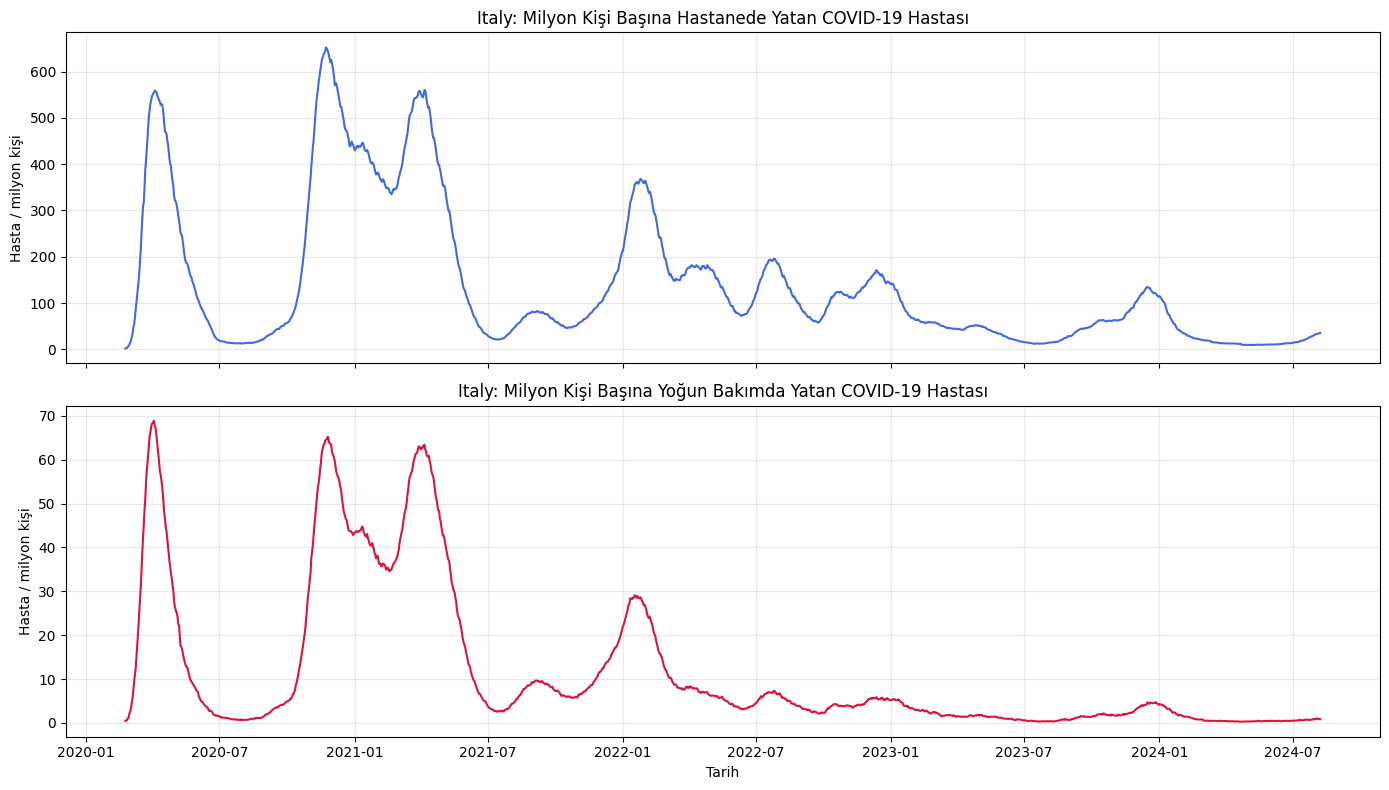

In [32]:
#İtalya için verilerin olduğu tarihler arasında hastane ve yoğun bakım verilerini  inceliyoruz
selected_country = 'Italy'

selected_patient_data = (
    df_countries.loc[
        (df_countries['location'] == selected_country)
        & df_countries['hosp_patients_per_million'].notna()
        & df_countries['icu_patients_per_million'].notna(),
        [
            'date',
            'hosp_patients_per_million',
            'icu_patients_per_million'
        ]
    ]
    .sort_values('date')
    .copy()
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True
)

axes[0].plot(
    selected_patient_data['date'],
    selected_patient_data['hosp_patients_per_million'],
    color='royalblue'
)

axes[0].set_title(
    f'{selected_country}: Milyon Kişi Başına Hastanede Yatan COVID-19 Hastası'
)

axes[0].set_ylabel('Hasta / milyon kişi')
axes[0].grid(alpha=0.3)

axes[1].plot(
    selected_patient_data['date'],
    selected_patient_data['icu_patients_per_million'],
    color='crimson'
)

axes[1].set_title(
    f'{selected_country}: Milyon Kişi Başına Yoğun Bakımda Yatan COVID-19 Hastası'
)

axes[1].set_xlabel('Tarih')
axes[1].set_ylabel('Hasta / milyon kişi')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
#reproduction_rate ile stringency_index aynı günlerde olup olmadığını kontrol ediyoruz
r_stringency_data = df_countries.loc[
    df_countries['reproduction_rate'].notna()
    & df_countries['stringency_index'].notna(),
    [
        'location',
        'date',
        'reproduction_rate',
        'stringency_index'
    ]
].copy()

r_stringency_coverage = (
    r_stringency_data
    .groupby('location')
    .agg(
        ilk_ortak_tarih=('date', 'min'),
        son_ortak_tarih=('date', 'max'),
        ortak_kayit_sayisi=('date', 'size')
    )
    .sort_values('ortak_kayit_sayisi', ascending=False)
)

print(r_stringency_coverage.head(20))

               ilk_ortak_tarih son_ortak_tarih  ortak_kayit_sayisi
location                                                          
China               2020-01-23      2022-12-31                1074
South Korea         2020-02-21      2022-12-31                1045
Japan               2020-02-22      2022-12-31                1044
Italy               2020-02-24      2022-12-31                1042
Iran                2020-02-27      2022-12-31                1039
France              2020-03-01      2022-12-31                1036
Singapore           2020-03-01      2022-12-31                1036
Germany             2020-03-02      2022-12-31                1035
Spain               2020-03-03      2022-12-31                1034
United Kingdom      2020-03-03      2022-12-31                1034
United States       2020-03-05      2022-12-31                1032
Switzerland         2020-03-06      2022-12-31                1031
Netherlands         2020-03-06      2022-12-31                

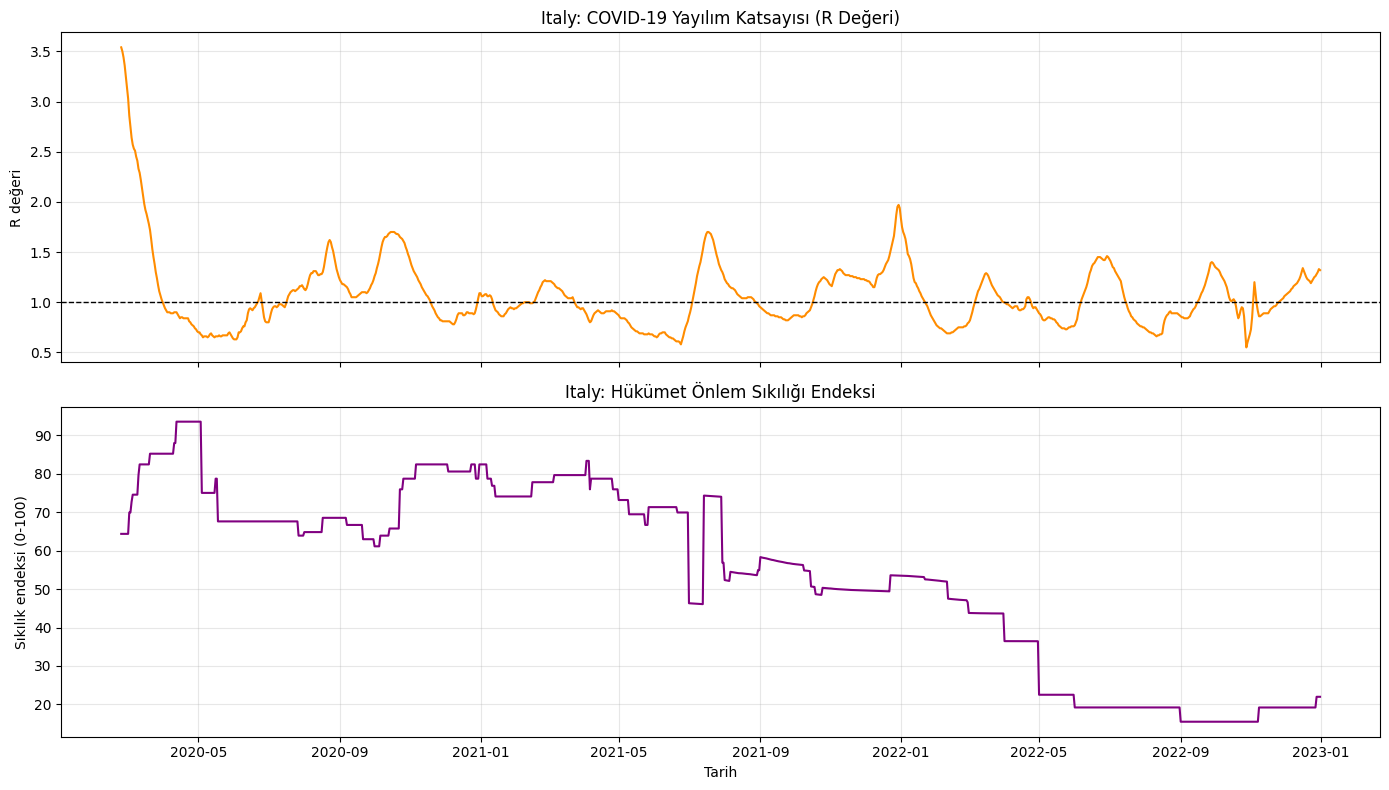

In [34]:
selected_r_stringency = (
    r_stringency_data.loc[
        r_stringency_data['location'] == selected_country
    ]
    .sort_values('date')
    .copy()
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True
)

axes[0].plot(
    selected_r_stringency['date'],
    selected_r_stringency['reproduction_rate'],
    color='darkorange'
)

axes[0].axhline(
    y=1,
    color='black',
    linestyle='--',
    linewidth=1
)

axes[0].set_title(
    f'{selected_country}: COVID-19 Yayılım Katsayısı (R Değeri)'
)

axes[0].set_ylabel('R değeri')
axes[0].grid(alpha=0.3)

axes[1].plot(
    selected_r_stringency['date'],
    selected_r_stringency['stringency_index'],
    color='purple'
)

axes[1].set_title(
    f'{selected_country}: Hükümet Önlem Sıkılığı Endeksi'
)

axes[1].set_xlabel('Tarih')
axes[1].set_ylabel('Sıkılık endeksi (0-100)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

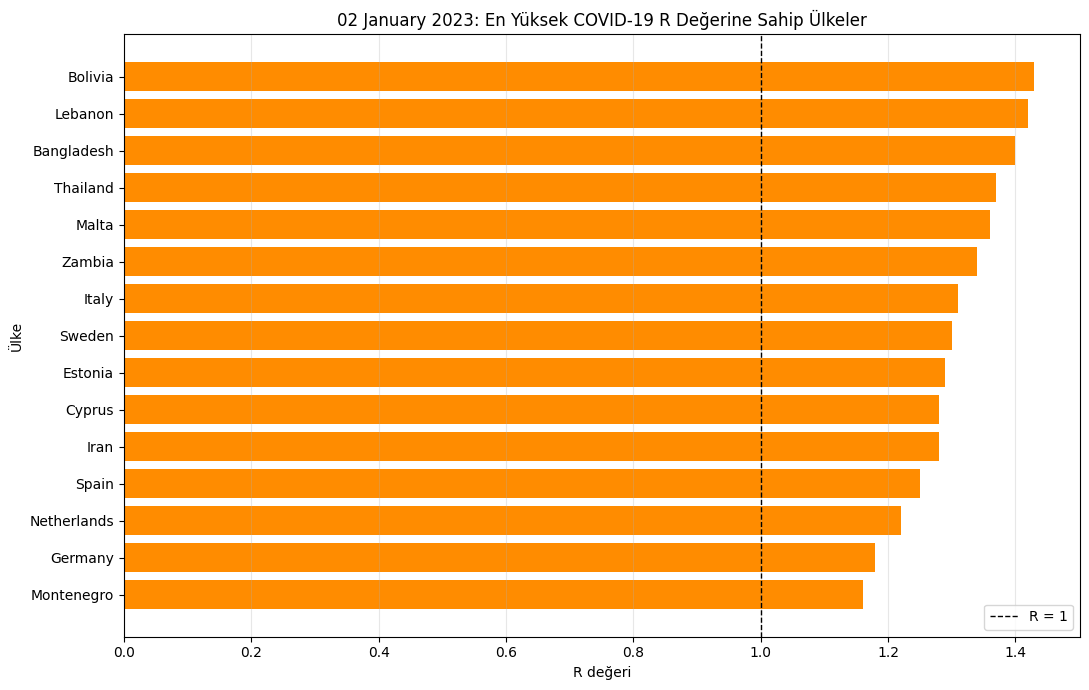

In [39]:
#Ülkeler için R değeri incelemek için ortak tarih seçiyoruz ve R değeri en yüksek 15 ülkeyi çiziyoruz
r_date_coverage = (
    r_valid_data
    .groupby('date')['location']
    .nunique()
    .sort_values(ascending=False)
)

max_r_country_count = r_date_coverage.max()

r_comparison_date = (
    r_date_coverage[
        r_date_coverage == max_r_country_count
    ]
    .index
    .max()
)

r_snapshot = (
    r_valid_data.loc[
        r_valid_data['date'] == r_comparison_date,
        ['location', 'reproduction_rate']
    ]
    .sort_values('reproduction_rate', ascending=False)
    .head(15)
)

plt.figure(figsize=(11, 7))

plt.barh(
    r_snapshot['location'],
    r_snapshot['reproduction_rate'],
    color='darkorange'
)

plt.axvline(
    x=1,
    color='black',
    linestyle='--',
    linewidth=1,
    label='R = 1'
)

plt.gca().invert_yaxis()

plt.title(
    f'{r_comparison_date:%d %B %Y}: En Yüksek COVID-19 R Değerine Sahip Ülkeler'
)

plt.xlabel('R değeri')
plt.ylabel('Ülke')
plt.legend()
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
#Hastane ve yoğun bakımı yükü için ortak tarihli ülke karşılaştırmasını buluyoruz
patient_comparison_data = df_countries.loc[
    df_countries['hosp_patients_per_million'].notna()
    & df_countries['icu_patients_per_million'].notna(),
    [
        'location',
        'date',
        'hosp_patients_per_million',
        'icu_patients_per_million'
    ]
].copy()

patient_date_coverage = (
    patient_comparison_data
    .groupby('date')['location']
    .nunique()
    .sort_values(ascending=False)
)

max_country_count = patient_date_coverage.max()

comparison_date = (
    patient_date_coverage[
        patient_date_coverage == max_country_count
    ]
    .index
    .max()
)

print('En yüksek ortak ülke sayısı:', max_country_count)
print('Karşılaştırma tarihi:', comparison_date)

En yüksek ortak ülke sayısı: 30
Karşılaştırma tarihi: 2022-02-13 00:00:00


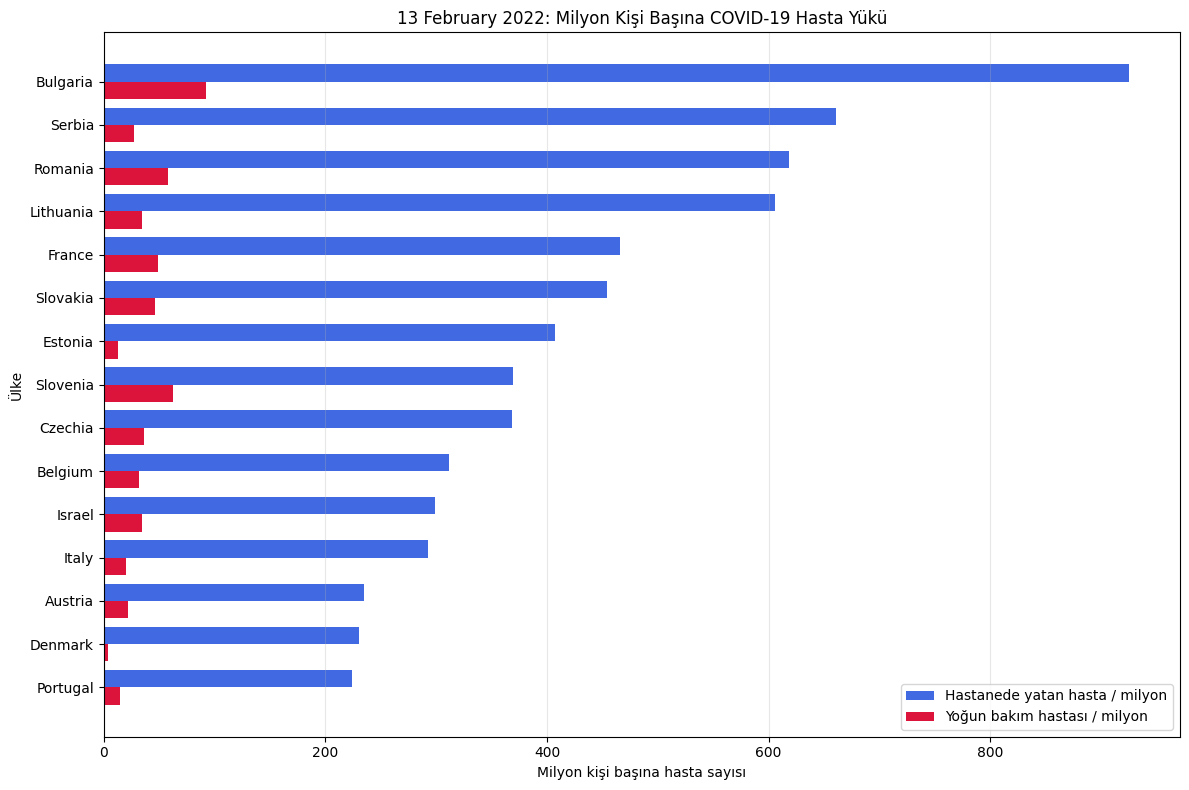

In [37]:
patient_snapshot = (
    patient_comparison_data.loc[
        patient_comparison_data['date'] == comparison_date
    ]
    .sort_values(
        'hosp_patients_per_million',
        ascending=False
    )
    .head(15)
    .copy()
)

positions = np.arange(len(patient_snapshot))

plt.figure(figsize=(12, 8))

plt.barh(
    positions - 0.2,
    patient_snapshot['hosp_patients_per_million'],
    height=0.4,
    label='Hastanede yatan hasta / milyon',
    color='royalblue'
)

plt.barh(
    positions + 0.2,
    patient_snapshot['icu_patients_per_million'],
    height=0.4,
    label='Yoğun bakım hastası / milyon',
    color='crimson'
)

plt.yticks(positions, patient_snapshot['location'])
plt.gca().invert_yaxis()

plt.title(
    f'{comparison_date:%d %B %Y}: Milyon Kişi Başına COVID-19 Hasta Yükü'
)

plt.xlabel('Milyon kişi başına hasta sayısı')
plt.ylabel('Ülke')
plt.legend()
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Bulgular ve Dashboard Kararları

### R değeri ve önlem sıkılığı

- `reproduction_rate`, salgının yayılma hızını gösterir. `R > 1` yayılımın artma, `R < 1` ise yavaşlama eğiliminde olduğunu ifade eder.
- R değeri 191 ülkede bulunmuştur. Her ülkenin R verisinin aktif kayıt aralığında aradaki günler eksiksizdir.
- R verisi kaynakta çoğunlukla 2 Ocak 2023 sonrasında bulunmadığı için R grafikleri bu tarih sonrasını kapsamamaktadır.
- 2 Ocak 2023 tarihinde 191 ülkenin R değeri birlikte bulunduğundan, ülkeler arası R karşılaştırması bu tarih üzerinden yapılmıştır.
- `stringency_index`, hükümetlerin okul/iş yeri kapanmaları, seyahat kısıtları ve benzeri önlemlerinin sıkılığını 0–100 aralığında gösterir.
- İtalya örneğinde R değeri ve önlem sıkılığı 24 Şubat 2020–31 Aralık 2022 arasında birlikte incelenmiştir.
- Bazı dönemlerde daha yüksek önlem sıkılığı ile daha düşük R değeri birlikte gözlense de bu durum nedensellik kanıtlamaz. Aşılama, varyantlar, test kapasitesi, davranış değişiklikleri ve önlemlerin gecikmeli etkisi de salgının yayılımını etkiler.

### Hastane ve yoğun bakım yükü

- `hosp_patients` ve `icu_patients`, belirli bir tarihte hastanede ve yoğun bakımda bulunan COVID-19 hasta sayılarını gösterir.
- Hastane hasta verisi 36 ülkede, yoğun bakım hasta verisi 38 ülkede bulunmuştur. Her iki göstergeyi birlikte paylaşan ülke sayısı 32’dir.
- Bazı ülkelerde hastane veya yoğun bakım verisinin aktif tarih aralığında boş günler bulunmaktadır. Bu boşluklar sıfır ile doldurulmamıştır.
- Hastane ve yoğun bakım verisi aktif döneminde kesintisiz olan 16 ülke belirlenmiştir. Uzun dönem zaman grafikleri için bu ülkeler tercih edilmelidir.
- İtalya; hastane ve yoğun bakım verisinin aynı tarih aralığında, 24 Şubat 2020–7 Ağustos 2024 arasında kesintisiz olması nedeniyle örnek zaman grafiği için kullanılmıştır.
- Ülkeler arası karşılaştırmada ham hasta sayısı yerine `hosp_patients_per_million` ve `icu_patients_per_million` kullanılmıştır. Böylece nüfus büyüklüğünün karşılaştırmayı yanıltması önlenmiştir.
- Milyon kişi başına değerler, ham hasta sayısı ve nüfus üzerinden yapılan hesaplamalarla tutarlıdır.
- 13 Şubat 2022 tarihinde 30 ülkenin hem hastane hem yoğun bakım verisi birlikte bulunmuştur. Bu tarihte Bulgaristan, milyon kişi başına hastane ve yoğun bakım hasta yükünde en yüksek ülkeler arasında yer almıştır.
- Bulgaristan’daki yüksek hastane yükü, Ocak sonu ve Şubat 2022’deki yüksek vaka ve ölüm yüküyle aynı döneme denk gelmektedir. Ancak bu durum tek başına sağlık sistemi kapasitesi veya tek bir faktörle açıklanamaz.

### Haftalık yatış ve yatak kapasitesi göstergeleri

- `weekly_hosp_admissions` ve `weekly_icu_admissions`, kaynak tarafından bildirilen haftalık hastane ve yoğun bakım yatış göstergeleridir.
- Bu göstergeler yalnızca sınırlı sayıda ülkede bulunur ve ülkeler arasında günlük veya haftalık farklı kayıt sıklıklarıyla paylaşılmıştır.
- Bu nedenle haftalık yatış göstergeleri yeniden toplanmamış, ana ülkeler arası karşılaştırmada kullanılmamıştır. Gerekirse seçili ülke detayında kaynak tarafından bildirilen değer olarak gösterilebilir.
- `hospital_beds_per_thousand`, bin kişi başına hastane yatağı kapasitesini gösteren sabit bir ülke bilgisidir. Günlük zaman serisi olarak değil, ülke bağlam göstergesi olarak kullanılacaktır.

### Dashboard Kararları

- R değeri için ülke karşılaştırması ve seçili ülke zaman grafiği sunulabilir; veri kapsamının 2023 başında bittiği belirtilmelidir.
- Hastane ve yoğun bakım zaman grafikleri yalnızca yeterli ve kesintisiz veri bulunan ülkeler için gösterilmelidir.
- Ülke karşılaştırmalarında milyon kişi başına hastane ve yoğun bakım göstergeleri kullanılmalıdır.
- Veri bulunmayan günler sıfır kabul edilmeyecek, grafiklerde boşluk olarak korunacaktır.
- Bu bölüm için ayrı bir işlenmiş CSV oluşturulmasına gerek yoktur; dashboard günlük göstergeleri `countries_clean.csv` dosyasından kullanabilir.